In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

This script calculates He and Ho similar to the way in previous script, but it takes into account monomorphic sites

# DATA with genotypes

In [2]:
inputs = pd.read_csv("01_prep_inputs.csv", sep=",", header=0, index_col=["id","POP"])
inputs.head()

,,55749196-29-G/A,100283399-40-C/T,100283400-45-A/C,55750931-10-C/T,23141276-42-T/A,100283428-17-C/T,100283429-66-T/A,23147835-9-C/T,100283457-18-C/A,55764801-6-G/A,...,13501202-27-G/A,55836668-31-A/C,23157730-22-T/G,55846148-65-T/C,55860316-28-G/C,55836449-6-T/C,55863991-48-C/T,102640963-40-T/A,55816615-37-A/G,102641000-63-A/G
id,POP,,,,,,,,,,,,,,,,,,,,,
E353-B1_3_6_333_001,333,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,0.0,NaN,0.0,0.0,2.0,NaN
E353-B1_3_6_6914_073,6914,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,1.0,2.0,0.0,0.0,0.0,2.0,1.0,NaN,2.0,NaN
E353-B1_3_16_6917_081,6917,0.0,0.0,2.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,...,2.0,NaN,1.0,0.0,NaN,2.0,NaN,0.0,2.0,2.0
E353-B3_3_7_6802_478,6802,0.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,2.0,1.0,NaN,NaN,NaN,0.0,0.0,2.0,NaN
E353-B3_3_14_6986_371,6986,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,NaN


In [3]:
print(inputs.shape)

(1460, 60900)


# Missing data per site

<Axes: >

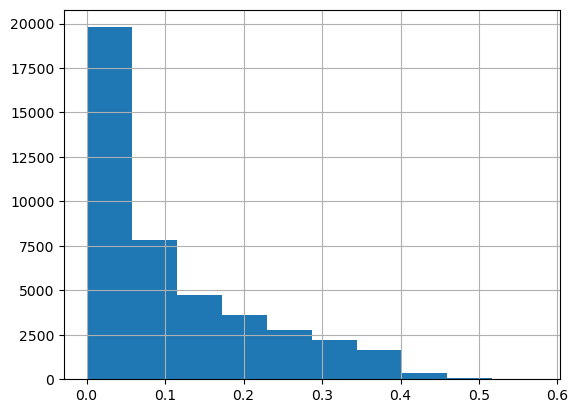

In [3]:
n_sites = inputs.shape[0]
frac_miss = 1 - (inputs.count()/n_sites)
frac_miss.hist()

In [4]:
print(frac_miss.shape)
print(frac_miss[frac_miss<0.01].shape)

(43001,)
(6337,)


# One population

In [6]:
pop = 6969
df = inputs.xs(key=pop, level="POP")
print(df.shape)
df.head()

(7, 43001)


,55749196-29-G/A,100283399-40-C/T,100283400-45-A/C,55750931-10-C/T,23141276-42-T/A,100283428-17-C/T,100283429-66-T/A,23147835-9-C/T,100283457-18-C/A,55764801-6-G/A,...,13501202-27-G/A,55836668-31-A/C,23157730-22-T/G,55846148-65-T/C,55860316-28-G/C,55836449-6-T/C,55863991-48-C/T,102640963-40-T/A,55816615-37-A/G,102641000-63-A/G
id,,,,,,,,,,,,,,,,,,,,,
E60-A_3_1_11_188,NaN,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,NaN,NaN,2.0,0.0,2.0,2.0
E60-A_3_2_11_189,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,NaN
E60-A_4_8_11_458,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,2.0,1.0,NaN,2.0,NaN
E60-A_6_2_11_455,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,0.0,2.0,0.0,NaN,0.0,NaN
E60-A_6_3_11_456,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,NaN,...,0.0,2.0,0.0,0.0,NaN,2.0,1.0,NaN,2.0,NaN


In [7]:
iteration = 1
subsample = 7

# Random subset of 7 samples
random_state = 7092025 + iteration + int(pop)
df_subset = df.sample(n=subsample, random_state=random_state)
print(df.shape, df_subset.shape)

# Remove missing sites

# fraction of genotyped samples = n genotyped samples / n rows (n=7)
# fraction of missing samples = 1 - fraction of genotyped samples
frac_miss = 1 - (df_subset.count()/df_subset.shape[0])
good_snps = frac_miss[frac_miss==0].index.values
df_filter = df_subset[good_snps]
print(df.shape, df_subset.shape, df_filter.shape)

# Only polymorphic sites: sum alleles 
df_sum = df_filter.sum()
polymorphic_snps = df_sum[(df_sum>0) & (df_sum<subsample*2)].index.values
df_poly = df_filter[polymorphic_snps]
print(df.shape, df_subset.shape, df_filter.shape, df_poly.shape)

# Number of polymorphic sites
n_poly = len(polymorphic_snps)

# Observed heterozygosity
df_ho = pd.DataFrame(df_poly[df_poly==1].count(axis=1)/df_poly.count(axis=1)).rename(columns={0:"ho"}).reset_index()
Ho = df_ho['ho'].mean()

# Expected heterozygosity
snps = df_poly.columns.values

S = []
for snp in snps:
    dsub_snp = df_poly[snp]
    word = ''.join(dsub_snp.astype(int).astype(str).values.tolist())
    n_ind = len(word)*2 # should be 14
    p_1 = ((word.count('0')*2) + word.count('1'))/n_ind
    p_2 = ((word.count('2')*2) + word.count('1'))/n_ind
    x = p_1**2 + p_2**2
    S.append(x)
He = 1 - (1/len(snps) * sum(S))

R = [pop, iteration, n_poly, Ho, He]
R

(7, 43001) (7, 43001)
(7, 43001) (7, 43001) (7, 24645)
(7, 43001) (7, 43001) (7, 24645) (7, 11031)


[6969, 1, 11031, 0.2550086120931919, 0.30636203352703606]

# Loop over pops

In [8]:
pops = inputs.reset_index()['POP'].drop_duplicates().values
pops

array([ 333, 6914, 6917, 6802, 6986,  325,  332, 6804, 6927, 7000,  321,
        338, 1528, 6968,  369, 1530, 4353,  342, 4277,  336, 1531, 4344,
       6930, 6973,  352, 1534, 4360, 1329, 6805, 3268, 6801, 6909, 6901,
       6988,  345,  355, 6922, 1538, 6938, 6979, 4351,  329, 6999,  326,
       6907, 6965, 6941, 6983, 6967, 6970, 6963, 6808, 2209, 6905, 6977,
       6964, 4420, 6916, 6972, 6980, 6971, 6956, 6969])

In [9]:
R = []
for pop in pops:
    print(pop)

    df = inputs.xs(key=pop, level="POP")
    print(df.shape)

    for iteration in range(5):
        subsample = 7
             
        # Random subset of 7 samples
        random_state = 7092025 + iteration + int(pop)
        df_subset = df.sample(n=subsample, random_state=random_state)
        #print(df.shape, df_subset.shape)
        
        # Remove missing sites
        frac_miss = 1 - (df_subset.count()/df_subset.shape[0])
        good_snps = frac_miss[frac_miss==0].index.values
        df_filter = df_subset[good_snps]
        #print(df.shape, df_subset.shape, df_filter.shape)
        
        # Only polymorphic sites: sum alleles 
        df_sum = df_filter.sum()
        polymorphic_snps = df_sum[(df_sum>0) & (df_sum<subsample*2)].index.values
        df_poly = df_filter[polymorphic_snps]
        print(df.shape, df_subset.shape, df_filter.shape, df_poly.shape)
        
        # Number of polymorphic sites
        n_poly = len(polymorphic_snps)
        
        # Observed heterozygosity
        df_ho = pd.DataFrame(df_filter[df_filter==1].count(axis=1)/df_filter.count(axis=1)).rename(columns={0:"ho"}).reset_index()
        Ho = df_ho['ho'].mean()
        
        # Expected heterozygosity
        snps = df_filter.columns.values
        
        S = []
        for snp in snps:
            dsub_snp = df_filter[snp]
            word = ''.join(dsub_snp.astype(int).astype(str).values.tolist())
            n_ind = len(word)*2 # should be 14
            p_1 = ((word.count('0')*2) + word.count('1'))/n_ind
            p_2 = ((word.count('2')*2) + word.count('1'))/n_ind
            x = p_1**2 + p_2**2
            S.append(x)
        He = 1 - (1/len(snps) * sum(S))
        
        result = [pop, iteration, n_poly, Ho, He]
        R.append(result)
dR = pd.DataFrame(R, columns = ["POP","iter","N_poly", "Ho", "He"])
dR.head()

333
(39, 43001)
(39, 43001) (7, 43001) (7, 24670) (7, 11783)
(39, 43001) (7, 43001) (7, 24785) (7, 11625)
(39, 43001) (7, 43001) (7, 25238) (7, 11743)
(39, 43001) (7, 43001) (7, 24303) (7, 11422)
(39, 43001) (7, 43001) (7, 25252) (7, 12196)
6914
(26, 43001)
(26, 43001) (7, 43001) (7, 23888) (7, 11578)
(26, 43001) (7, 43001) (7, 25211) (7, 12328)
(26, 43001) (7, 43001) (7, 24110) (7, 11626)
(26, 43001) (7, 43001) (7, 23954) (7, 11436)
(26, 43001) (7, 43001) (7, 24402) (7, 11766)
6917
(15, 43001)
(15, 43001) (7, 43001) (7, 24170) (7, 11345)
(15, 43001) (7, 43001) (7, 24162) (7, 11600)
(15, 43001) (7, 43001) (7, 23862) (7, 11239)
(15, 43001) (7, 43001) (7, 24530) (7, 11616)
(15, 43001) (7, 43001) (7, 24114) (7, 11690)
6802
(21, 43001)
(21, 43001) (7, 43001) (7, 24208) (7, 11851)
(21, 43001) (7, 43001) (7, 24089) (7, 11960)
(21, 43001) (7, 43001) (7, 24506) (7, 11976)
(21, 43001) (7, 43001) (7, 24011) (7, 11552)
(21, 43001) (7, 43001) (7, 24092) (7, 11523)
6986
(31, 43001)
(31, 43001) (7, 

,POP,iter,N_poly,Ho,He
0,333,0,11783,0.116608,0.142486
1,333,1,11625,0.117127,0.140840
2,333,2,11743,0.119185,0.138089
3,333,3,11422,0.117199,0.139683
4,333,4,12196,0.121388,0.142891


In [10]:
dR.head()

,POP,iter,N_poly,Ho,He
0,333,0,11783,0.116608,0.142486
1,333,1,11625,0.117127,0.140840
2,333,2,11743,0.119185,0.138089
3,333,3,11422,0.117199,0.139683
4,333,4,12196,0.121388,0.142891


In [11]:
dR["Ho"].describe()

count    315.000000
mean       0.114851
std        0.005695
min        0.099838
25%        0.111965
50%        0.115809
75%        0.119058
max        0.129461
Name: Ho, dtype: float64

In [12]:
dR.to_csv("04_calculate_heterozygosity_all_sites.tsv", sep="\t", header=True, index=False)

In [13]:
dR.shape

(315, 5)

<Axes: xlabel='Ho', ylabel='He'>

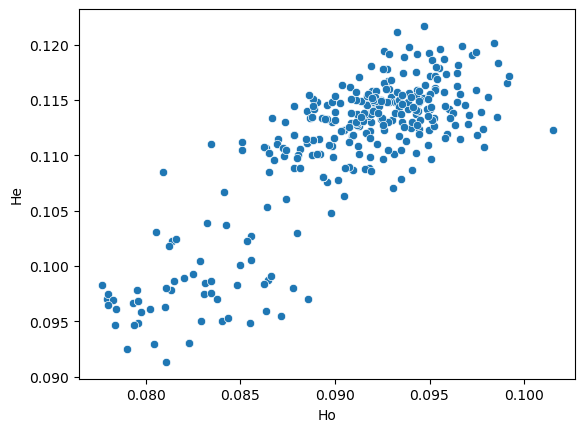

In [19]:
sns.scatterplot(data=dR, x = "Ho", y = "He")

<Axes: xlabel='N_poly', ylabel='Ho'>

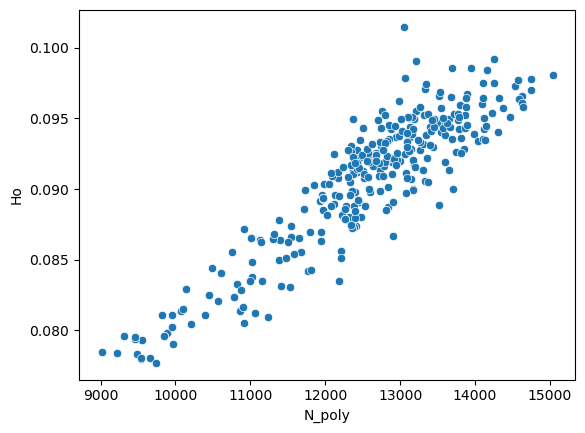

In [20]:
sns.scatterplot(data=dR, x = "N_poly", y = "Ho")